--- Reading Alberto's Posterior File: smbh_pt_8modes_Q3d_290.h5 ---
Loaded 10240 posterior samples after removing burn-in!
Kept 10240 high-quality samples after lnL cut!


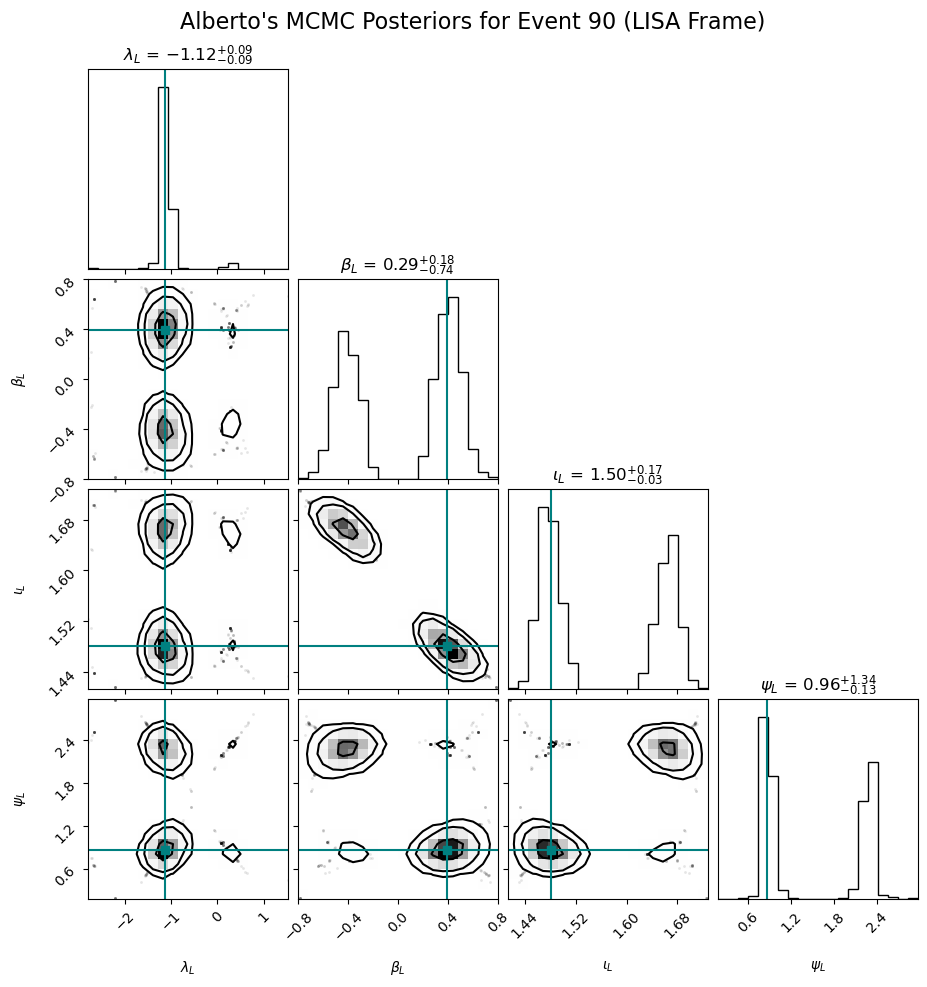

In [15]:
import os
import h5py
import glob
import numpy as np
import corner
import matplotlib.pyplot as plt

repo_path = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs"
pop_name = "Q3d"
event_id = 90  # 8-mode event!

h5_matches = glob.glob(os.path.join(repo_path, pop_name, "inference_data", f"*{event_id}*.h5"))
h5_path = h5_matches[0]

print(f"--- Reading Alberto's Posterior File: {os.path.basename(h5_path)} ---")

with h5py.File(h5_path, 'r') as f:
    # 1. EXTRACT TRUE VALUES IN THE LISA FRAME
    true_dict = {}
    if 'source_params_Lframe' in f:
        sp = f['source_params_Lframe']
        for name in sp.keys():
            val = sp[name][()]
            # Handle both scalar values and 1D arrays of length 1
            true_dict[name] = val[0] if isinstance(val, np.ndarray) else val
                
    labels = [r"$\lambda_L$", r"$\beta_L$", r"$\iota_L$", r"$\psi_L$"]
    plot_data = []
    truths = []
    
    # 2. EXTRACT CHAINS IN THE LISA FRAME
    for param in ['lambda', 'beta', 'inc', 'psi']:
        # Pull from the 'Lframe' group if it exists, otherwise from the root
        if 'Lframe' in f and param in f['Lframe']:
            chain = f['Lframe'][param][:]
        else:
            chain = f[param][:]
        
        # 3. CRITICAL: CUT THE BURN-IN! (Discard the first 50% of the random walking)
        if len(chain.shape) == 3:
            # (Temperatures, Walkers, Steps) -> Take Coldest Temp, keep second half of steps
            chain_burned = chain[0, :, chain.shape[2]//2:]
        elif len(chain.shape) == 2:
            chain_burned = chain[:, chain.shape[1]//2:]
        else:
            chain_burned = chain
            
        plot_data.append(chain_burned.flatten())
        truths.append(true_dict.get(param, 0.0))
        
    samples = np.column_stack(plot_data)
    print(f"Loaded {samples.shape[0]} posterior samples after removing burn-in!")
    
    # 4. FILTER BAD LIKELIHOODS (Exactly what Alberto did in his script!)
    if 'lnlike' in f:
        lnL = f['lnlike'][:]
        if len(lnL.shape) == 3:
            lnL_burned = lnL[0, :, lnL.shape[2]//2:].flatten()
        elif len(lnL.shape) == 2:
            lnL_burned = lnL[:, lnL.shape[1]//2:].flatten()
        else:
            lnL_burned = lnL
            
        mask = lnL_burned > -40.0
        
        # Make sure mask matches samples size (just in case shapes differ)
        if len(mask) == samples.shape[0]:
            samples = samples[mask]
            print(f"Kept {samples.shape[0]} high-quality samples after lnL cut!")

    # 5. PLOT!
    fig = corner.corner(
        samples, 
        labels=labels, 
        truths=truths,
        truth_color='teal',
        show_titles=True, 
        title_kwargs={"fontsize": 12},
        hist_kwargs={'density': True},
        smooth=0.8,
        fill_contours=False,
        levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-3) )
    )
    fig.suptitle(f"Alberto's MCMC Posteriors for Event {event_id} (LISA Frame)", fontsize=16, y=1.02)
    plt.show()

Loading Dataset: dataset_ae_stft_phase_50k.h5...
Loading U-Net Checkpoint...
Generating 2000 Network Posteriors (Running ODE Solver)...
Loading Alberto's MCMC Posteriors for Event 0...
Plotting Comparison...


ValueError: Provided figure has 16 axes, but data has dimensions K=0

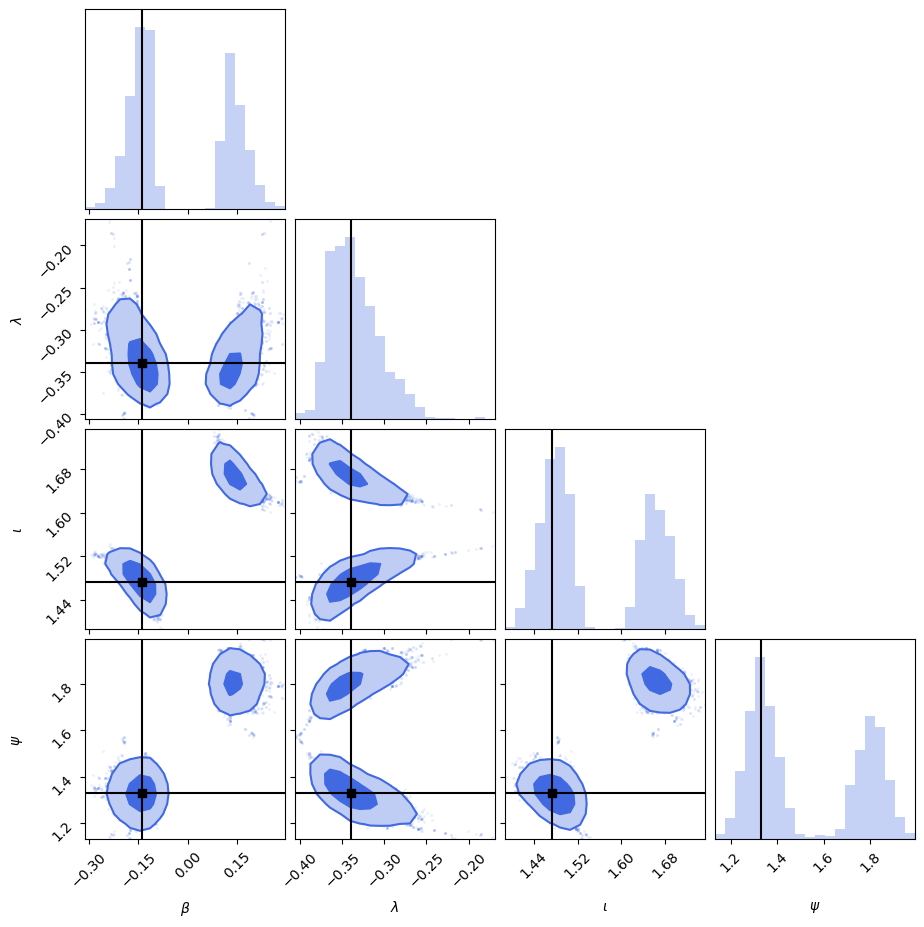

In [3]:
import os
import sys
import h5py
import glob
import torch
import numpy as np
import corner
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torchdiffeq

# Add your repository to the path so we can import the UNet!
sys.path.append("/sps/lisaf/mbellotti/github/lisaflow_cfm")
from torchcfm.models.unet import UNetModel

# Import your EXACT dataloader so we get perfect normalization!
from examples.gw_mbhb.train_mbhb_malvi import LISAFlowDataset

# ==============================================================================
# 1. SETUP PATHS
# ==============================================================================
# ---> CHANGE THESE TO MATCH YOUR LATEST RUN! <---
# JOB_ID = "43194143"  # The SLURM job ID of your training run
# JOB_ID = "42894068"
JOB_ID = "43338450"
# DATASET_NAME = "dataset_ae_stft_phase_100k.h5" # The file you trained on
DATASET_NAME = "dataset_ae_stft_phase_50k.h5"


TRAIN_DIR = "/sps/lisaf/mbellotti/github/lisaflow_cfm/examples/gw_mbhb"
checkpoint_path = os.path.join(TRAIN_DIR, f"malvis_tests/outputs/job_{JOB_ID}", "checkpoint_latest.pt")
dataset_path = os.path.join("/sps/lisaf/mbellotti/github/mbhb_time_frequency/data", DATASET_NAME)
# dataseth_path = os.path.join("/sps/lisaf/mbellotti/github/phd_disentangling/scripts/data", DATASET_NAME)
# Alberto's Event
alberto_repo = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs"
pop_name = "Q3d"
event_id = 0

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading Dataset: {DATASET_NAME}...")
param_names = ['beta', 'lam', 'inc', 'psi']
# param_names = ['t_ref', 'm1', 'm2', 'dist', 'beta', 'lam', 'inc', 'psi']

dataset = LISAFlowDataset(dataset_path, param_names)

# ==============================================================================
# 2. GENERATE FLOW MATCHING POSTERIORS
# ==============================================================================
# Get the VERY LAST event in the dataset (which is Alberto's test event!)
target_params_norm, target_img_norm = dataset[-1]

target_img_norm = target_img_norm.unsqueeze(0).to(device)
features_size = len(param_names)

# Crop the image exactly like your training script does
H, W = target_img_norm.shape[-2], target_img_norm.shape[-1]
H_new, W_new = H - (H % 16), W - (W % 16)
target_img_norm = target_img_norm[:, :, :H_new, :W_new]
img_shape = (target_img_norm.shape[1], H_new, W_new)

print("Loading U-Net Checkpoint...")
model = UNetModel(
    dimx=(features_size, 1, 1), dimy=img_shape, 
    num_channels=32, num_res_blocks=1, channel_mult=(1, 2, 2), 
    class_cond=False, use_checkpoint=True, attention_resolutions="16"
).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("Generating 2000 Network Posteriors (Running ODE Solver)...")
num_samples = 1000
with torch.no_grad():
    # Condition on the same image 2000 times
    img_batch = target_img_norm.expand(num_samples, -1, -1, -1)
    
    # Start from random Gaussian noise
    z0 = torch.randn((num_samples, features_size)).to(device).unsqueeze(1)
    
    # Solve ODE
    traj = torchdiffeq.odeint(
        lambda t, x: model.forward(t, x, img_batch, timefrequency=True), 
        z0,
        torch.linspace(0, 1, 50, device=device), 
        method="euler"
    )
    
    samples_norm = traj[-1].view(num_samples, features_size).cpu().numpy()

# Un-normalize back to physical parameters
network_samples = samples_norm * dataset.param_std + dataset.param_mean

# ==============================================================================
# 3. LOAD ALBERTO'S MCMC POSTERIORS
# ==============================================================================
print(f"Loading Alberto's MCMC Posteriors for Event {event_id}...")
h5_matches = glob.glob(os.path.join(alberto_repo, pop_name, "inference_data", f"*{event_id}*.h5"))
alberto_path = h5_matches[0]

true_dict = {}
plot_data = []

with h5py.File(alberto_path, 'r') as f:
    if 'source_params_Lframe' in f:
        sp = f['source_params_Lframe']
        for name in sp.keys():
            val = sp[name][()]
            true_dict[name] = val[0] if isinstance(val, np.ndarray) else val
            
    # Load chains using the exact same order as your network (beta, lam, inc, psi)
    for param in ['beta', 'lambda', 'inc', 'psi']:
        chain = f['Lframe'][param][:] if ('Lframe' in f and param in f['Lframe']) else f[param][:]
        
        # Remove Burn-in safely for any dimension size
        if len(chain.shape) == 3: 
            chain_burned = chain[0, :, chain.shape[2]//2:]
        elif len(chain.shape) == 2: 
            chain_burned = chain[:, chain.shape[1]//2:]
        else: 
            chain_burned = chain[chain.shape[0]//2:] # 1D case
            
        plot_data.append(chain_burned.flatten())

    alberto_samples = np.column_stack(plot_data)

    # Filter bad likelihoods safely for any dimension size!
    if 'lnlike' in f:
        lnL = f['lnlike'][:]
        if len(lnL.shape) == 3:
            lnL_burned = lnL[0, :, lnL.shape[2]//2:].flatten()
        elif len(lnL.shape) == 2:
            lnL_burned = lnL[:, lnL.shape[1]//2:].flatten()
        else:
            lnL_burned = lnL[lnL.shape[0]//2:].flatten() # 1D case
            
        mask = lnL_burned > -40.0
        if len(mask) == alberto_samples.shape[0]:
            alberto_samples = alberto_samples[mask]

# ==============================================================================
# 4. PLOT COMPARISON
# ==============================================================================
print("Plotting Comparison...")
labels = [r"$\beta$", r"$\lambda$", r"$\iota$", r"$\psi$"]
truths = [true_dict.get('beta', 0), true_dict.get('lambda', 0), true_dict.get('inc', 0), true_dict.get('psi', 0)]

# 1. Plot Alberto's MCMC (in Blue)
fig = corner.corner(
# alberto_samples[:4], 
    alberto_samples,
    labels=labels, 
    truths=truths,
    truth_color='black',
    color='royalblue',
    hist_kwargs={'density': True, 'histtype': 'stepfilled', 'alpha': 0.3},
    smooth=0.8,
    fill_contours=True,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)

# 2. Overplot Network Posteriors (in Orange)
corner.corner(
        network_samples[:, 4:],  # <--- SLICE OUT ONLY THE ANGLES!
        fig=fig, 
        color='darkorange',
        hist_kwargs={'density': True, 'histtype': 'step', 'linewidth': 2},
        smooth=0.8, fill_contours=False, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
    )

# Custom Legend
custom_lines = [
    Line2D([0], [0], color='royalblue', lw=4, alpha=0.5, label='Alberto MCMC'),
    Line2D([0], [0], color='darkorange', lw=2, label='Flow Matching UNet'),
    Line2D([0], [0], color='black', lw=2, label='True Injected Value')
]
fig.legend(handles=custom_lines, loc='upper right', fontsize=14, bbox_to_anchor=(0.95, 0.95))

fig.suptitle(f"Posterior Comparison: Flow Matching vs MCMC (Event {event_id})", fontsize=18, y=1.02)
plt.show()

In [5]:
import h5py
import numpy as np

# Your fixed ML parameters
target_m1 = 5.00e05
target_dl = 15000.0

# Path to Alberto's summary file
alberto_h5 = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs/data_for_Malvina.h5"

print(f"Hunting for an event close to M1 = {target_m1:.2e} and DL = {target_dl}...\n")

with h5py.File(alberto_h5, 'r') as f:
    for pop_name in ['Q3d', 'Pop3', 'Q3nd']:
        if pop_name not in f: continue
        
        pop_group = f[pop_name]
        results = []
        
        for strid in pop_group.keys():
            ev = pop_group[strid]
            m1 = ev['m1'][()]
            z = ev['z'][()]
            dl = ev['DL_Mpc'][()]
            stsi = int(ev['StSi_index'][()])
            
            # The network sees the detector-frame mass!
            m1_det = m1 * (1 + z) 
            
            # Calculate a normalized distance (so mass and distance are weighted equally)
            diff = ((m1_det - target_m1) / target_m1)**2 + ((dl - target_dl) / target_dl)**2
            
            results.append((diff, stsi, m1_det, dl))
            
        # Sort by closest match
        results.sort(key=lambda x: x[0])
        
        print(f"--- Top 3 closest events in {pop_name} ---")
        for r in results[:3]:
            print(f"Event ID: {r[1]:<4} | M1_det: {r[2]:.2e} M_sun | DL: {r[3]:.2f} Mpc")
        print()

Hunting for an event close to M1 = 5.00e+05 and DL = 15000.0...

--- Top 3 closest events in Q3d ---
Event ID: 282  | M1_det: 4.88e+05 M_sun | DL: 15097.46 Mpc
Event ID: 448  | M1_det: 5.26e+05 M_sun | DL: 15373.24 Mpc
Event ID: 128  | M1_det: 4.93e+05 M_sun | DL: 16529.04 Mpc

--- Top 3 closest events in Pop3 ---
Event ID: 1200 | M1_det: 4.51e+05 M_sun | DL: 15099.39 Mpc
Event ID: 458  | M1_det: 4.21e+05 M_sun | DL: 14705.47 Mpc
Event ID: 1102 | M1_det: 4.52e+05 M_sun | DL: 12134.59 Mpc

--- Top 3 closest events in Q3nd ---
Event ID: 1055 | M1_det: 5.02e+05 M_sun | DL: 15536.74 Mpc
Event ID: 867  | M1_det: 5.02e+05 M_sun | DL: 13092.40 Mpc
Event ID: 1256 | M1_det: 4.35e+05 M_sun | DL: 14302.07 Mpc




--- Loading Alberto's MCMC Posteriors for Event 282 ---

--- Loading ML Dataset: dataset_ae_stft_phase_50k.h5 ---

=== INTRINSIC PARAMETER CHECK ===
Alberto M1: 4.88e+05 M_sun  | ML Dataset M1: 5.00e+05 M_sun
Alberto DL: 15097.46 Mpc | ML Dataset DL: 15000.00 Mpc

Loading U-Net Checkpoint...
Generating 1000 Network Posteriors (Running ODE Solver)...
Plotting Comparison...
Saved plot to comparison_event_282.png


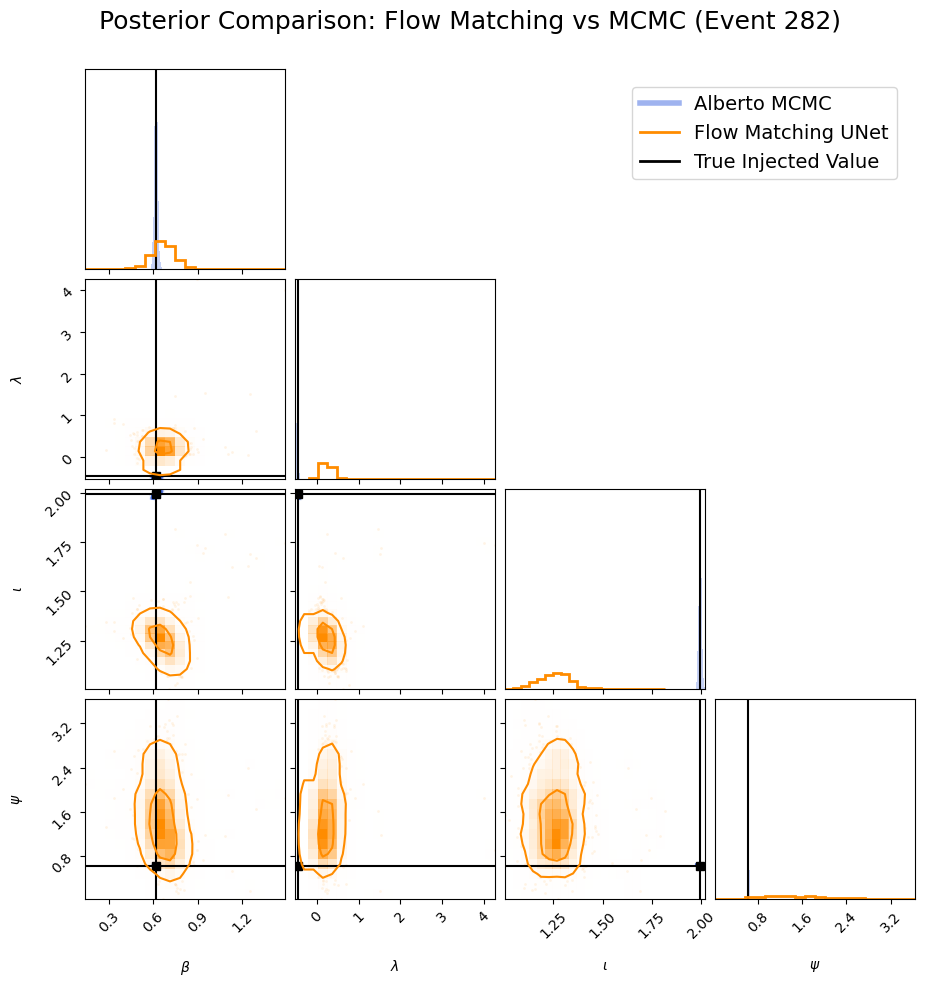

In [6]:
import os
import sys
import h5py
import glob
import torch
import numpy as np
import corner
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torchdiffeq
from bbhx.utils.constants import PC_SI

# Add your repository to the path so we can import the UNet!
sys.path.append("/sps/lisaf/mbellotti/github/lisaflow_cfm")
from torchcfm.models.unet import UNetModel

# Import your EXACT dataloader so we get perfect normalization!
from examples.gw_mbhb.train_mbhb_malvi import LISAFlowDataset

# ==============================================================================
# 1. SETUP PATHS
# ==============================================================================
JOB_ID = "43338450"
DATASET_NAME = "dataset_ae_stft_phase_50k.h5"

TRAIN_DIR = "/sps/lisaf/mbellotti/github/lisaflow_cfm/examples/gw_mbhb"
checkpoint_path = os.path.join(TRAIN_DIR, f"malvis_tests/outputs/job_{JOB_ID}", "checkpoint_latest.pt")
dataset_path = os.path.join("/sps/lisaf/mbellotti/github/mbhb_time_frequency/data", DATASET_NAME)

# Alberto's Event
alberto_repo = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs"
pop_name = "Q3d"
event_id = 282  # <--- The exact StSi index we want to test

device = "cuda" if torch.cuda.is_available() else "cpu"

# ==============================================================================
# 2. LOAD ALBERTO'S MCMC POSTERIORS & TRUE VALUES FIRST
# ==============================================================================
print(f"\n--- Loading Alberto's MCMC Posteriors for Event {event_id} ---")
# Note: Double check if Alberto's folder is named "data_inference" or "inference_data"!
h5_matches = glob.glob(os.path.join(alberto_repo, pop_name, "*inference*", f"*{event_id}*.h5"))

if not h5_matches:
    raise FileNotFoundError(f"Could not find Alberto's MCMC file for event {event_id}!")

alberto_path = h5_matches[0]
true_dict = {}
plot_data = []

with h5py.File(alberto_path, 'r') as f:
    # 1. Get Alberto's true injected values
    if 'source_params_Lframe' in f:
        sp = f['source_params_Lframe']
        for name in sp.keys():
            val = sp[name][()]
            true_dict[name] = val[0] if isinstance(val, np.ndarray) else val
            
    # 2. Extract MCMC chains
    for param in ['beta', 'lambda', 'inc', 'psi']:
        chain = f['Lframe'][param][:] if ('Lframe' in f and param in f['Lframe']) else f[param][:]
        
        if len(chain.shape) == 3: chain_burned = chain[0, :, chain.shape[2]//2:]
        elif len(chain.shape) == 2: chain_burned = chain[:, chain.shape[1]//2:]
        else: chain_burned = chain[chain.shape[0]//2:]
            
        plot_data.append(chain_burned.flatten())

    alberto_samples = np.column_stack(plot_data)

    if 'lnlike' in f:
        lnL = f['lnlike'][:]
        if len(lnL.shape) == 3: lnL_burned = lnL[0, :, lnL.shape[2]//2:].flatten()
        elif len(lnL.shape) == 2: lnL_burned = lnL[:, lnL.shape[1]//2:].flatten()
        else: lnL_burned = lnL[lnL.shape[0]//2:].flatten()
            
        mask = lnL_burned > -40.0
        if len(mask) == alberto_samples.shape[0]:
            alberto_samples = alberto_samples[mask]

# ==============================================================================
# 3. MATCH EVENT IN ML DATASET & CHECK INTRINSIC PARAMS
# ==============================================================================
print(f"\n--- Loading ML Dataset: {DATASET_NAME} ---")
param_names = ['beta', 'lam', 'inc', 'psi']
dataset = LISAFlowDataset(dataset_path, param_names)

# We must search the ML dataset to find the EXACT image that matches Alberto's Event 0
true_lam = true_dict.get('lambda', true_dict.get('lam', 0))
true_beta = true_dict.get('beta', 0)

# Calculate distance between all ML events and Alberto's event
diff = (dataset.raw_param_dict['lam'] - true_lam)**2 + (dataset.raw_param_dict['beta'] - true_beta)**2
best_idx = np.argmin(diff)

print("\n=== INTRINSIC PARAMETER CHECK ===")
ml_m1 = dataset.raw_param_dict['m1'][best_idx]
ml_dist = dataset.raw_param_dict['dist'][best_idx] / (1e6 * PC_SI) # Convert back to Mpc

# If Alberto's file doesn't have m1 natively, we compute it from mchirp and q
if 'm1' in true_dict:
    alberto_m1 = true_dict['m1']
else:
    mc, q_val = true_dict.get('mchirp', 0), true_dict.get('q', 1)
    m_A = mc * (1.0 + q_val)**0.2 / (q_val**0.6)
    alberto_m1 = max(m_A, m_A * q_val)

alberto_dist = true_dict.get('dL', true_dict.get('dist', true_dict.get('DL_Mpc', 0)))
if alberto_dist > 1e6: alberto_dist /= (1e6 * PC_SI) # Ensure it's in Mpc

print(f"Alberto M1: {alberto_m1:.2e} M_sun  | ML Dataset M1: {ml_m1:.2e} M_sun")
print(f"Alberto DL: {alberto_dist:.2f} Mpc | ML Dataset DL: {ml_dist:.2f} Mpc")
print("=================================\n")

# Get the perfectly matched image!
target_params_norm, target_img_norm = dataset[best_idx]
target_img_norm = target_img_norm.unsqueeze(0).to(device)
features_size = len(param_names)

# Crop image
H, W = target_img_norm.shape[-2], target_img_norm.shape[-1]
H_new, W_new = H - (H % 16), W - (W % 16)
target_img_norm = target_img_norm[:, :, :H_new, :W_new]
img_shape = (target_img_norm.shape[1], H_new, W_new)

# ==============================================================================
# 4. GENERATE FLOW MATCHING POSTERIORS
# ==============================================================================
print("Loading U-Net Checkpoint...")
model = UNetModel(
    dimx=(features_size, 1, 1), dimy=img_shape, 
    num_channels=32, num_res_blocks=1, channel_mult=(1, 2, 2), 
    class_cond=False, use_checkpoint=True, attention_resolutions="16"
).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=False)['model_state_dict'])
model.eval()

print("Generating 1000 Network Posteriors (Running ODE Solver)...")
num_samples = 1000
with torch.no_grad():
    img_batch = target_img_norm.expand(num_samples, -1, -1, -1)
    z0 = torch.randn((num_samples, features_size)).to(device).unsqueeze(1)
    traj = torchdiffeq.odeint(
        lambda t, x: model.forward(t, x, img_batch, timefrequency=True), 
        z0, torch.linspace(0, 1, 50, device=device), method="euler"
    )
    samples_norm = traj[-1].view(num_samples, features_size).cpu().numpy()

# Un-normalize back to physical parameters
network_samples = samples_norm * dataset.param_std + dataset.param_mean

# ==============================================================================
# 5. PLOT COMPARISON
# ==============================================================================
print("Plotting Comparison...")
labels = [r"$\beta$", r"$\lambda$", r"$\iota$", r"$\psi$"]
truths = [true_beta, true_lam, true_dict.get('inc', 0), true_dict.get('psi', 0)]

# 1. Plot Alberto's MCMC (in Blue)
fig = corner.corner(
    alberto_samples,
    labels=labels, 
    truths=truths,
    truth_color='black',
    color='royalblue',
    hist_kwargs={'density': True, 'histtype': 'stepfilled', 'alpha': 0.3},
    smooth=0.8,
    fill_contours=True,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)

# 2. Overplot Network Posteriors (in Orange)
corner.corner(
    network_samples,  # <--- FIXED SLICE BUG!
    fig=fig, 
    color='darkorange',
    hist_kwargs={'density': True, 'histtype': 'step', 'linewidth': 2},
    smooth=0.8, fill_contours=False, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)

# Custom Legend
custom_lines = [
    Line2D([0], [0], color='royalblue', lw=4, alpha=0.5, label='Alberto MCMC'),
    Line2D([0], [0], color='darkorange', lw=2, label='Flow Matching UNet'),
    Line2D([0], [0], color='black', lw=2, label='True Injected Value')
]
fig.legend(handles=custom_lines, loc='upper right', fontsize=14, bbox_to_anchor=(0.95, 0.95))

fig.suptitle(f"Posterior Comparison: Flow Matching vs MCMC (Event {event_id})", fontsize=18, y=1.02)
plt.savefig(f"comparison_event_{event_id}.png", dpi=150, bbox_inches='tight')
# print(f"Saved plot to comparison_event_{event_id}.png")

In [2]:
import os
import sys
import h5py
import glob
import torch
import numpy as np
import corner
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torchdiffeq
from bbhx.utils.constants import PC_SI

# Add your repository to the path so we can import the UNet!
sys.path.append("/sps/lisaf/mbellotti/github/lisaflow_cfm")
from torchcfm.models.unet import UNetModel
from examples.gw_mbhb.train_mbhb_malvi import LISAFlowDataset

# ==============================================================================
# 1. SETUP PATHS
# ==============================================================================
JOB_ID = "42827953"  # Your full parameter space run

DATASET_NAME = "dataset_ae_stft_phase_100k.h5" 

TRAIN_DIR = "/sps/lisaf/mbellotti/github/lisaflow_cfm/examples/gw_mbhb"
checkpoint_path = os.path.join(TRAIN_DIR, f"malvis_tests/outputs/job_{JOB_ID}", "checkpoint_latest.pt")
# dataset_path = os.path.join("/sps/lisaf/mbellotti/github/mbhb_time_frequency/data", DATASET_NAME)
dataset_path = os.path.join("/sps/lisaf/mbellotti/github/phd_disentangling/scripts/data", DATASET_NAME)
alberto_repo = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs"
pop_name = "Q3d"


event_id = 86  # Choose the event you want to compare

device = "cuda" if torch.cuda.is_available() else "cpu"

# The parameters your network predicted
# param_names = ['m1', 'q', 'dist', 'beta', 'lam', 'inc', 'psi']
param_names = ['t_ref', 'm1', 'm2', 'dist', 'beta', 'lam', 'inc', 'psi']

dataset = LISAFlowDataset(dataset_path, param_names)

# ==============================================================================
# 2. LOAD ALBERTO'S 4D MCMC POSTERIORS
# ==============================================================================
print(f"--- Loading Extrinsic MCMC Posteriors for Event {event_id} ---")
h5_matches = glob.glob(os.path.join(alberto_repo, pop_name, "*inference*", f"*{event_id}*.h5"))
if not h5_matches: raise FileNotFoundError(f"Could not find MCMC file for event {event_id}!")

mcmc_dict = {}
true_dict = {}

with h5py.File(h5_matches[0], 'r') as f:
    # Get True Values
    if 'source_params_Lframe' in f:
        sp = f['source_params_Lframe']
        for name in sp.keys():
            val = sp[name][()]
            true_dict[name] = val[0] if isinstance(val, np.ndarray) else val

    # Load only the 4 extrinsic chains
    for param in ['beta', 'lambda', 'inc', 'psi']:
        chain = f['Lframe'][param][:] if ('Lframe' in f and param in f['Lframe']) else f.get(param, None)
        if chain is not None:
            if len(chain.shape) == 3: chain = chain[0, :, chain.shape[2]//2:]
            elif len(chain.shape) == 2: chain = chain[:, chain.shape[1]//2:]
            else: chain = chain[chain.shape[0]//2:]
            mcmc_dict[param] = chain.flatten()
            
    # Filter by likelihood
    if 'lnlike' in f:
        lnL = f['lnlike'][:]
        if len(lnL.shape) == 3: lnL = lnL[0, :, lnL.shape[2]//2:].flatten()
        elif len(lnL.shape) == 2: lnL = lnL[:, lnL.shape[1]//2:].flatten()
        else: lnL = lnL[lnL.shape[0]//2:].flatten()
        mask = lnL > -40.0
        for k in mcmc_dict:
            if len(mcmc_dict[k]) == len(mask):
                mcmc_dict[k] = mcmc_dict[k][mask]

# Stack MCMC into a 4D array: [beta, lam, inc, psi]
mcmc_extrinsic_samples = np.column_stack([
    mcmc_dict['beta'], mcmc_dict['lambda'], mcmc_dict['inc'], mcmc_dict['psi']
])

true_extrinsic = [
    true_dict.get('beta', np.median(mcmc_dict['beta'])),
    true_dict.get('lambda', np.median(mcmc_dict['lambda'])),
    true_dict.get('inc', np.median(mcmc_dict['inc'])),
    true_dict.get('psi', np.median(mcmc_dict['psi']))
]

# ==============================================================================
# 3. FIND EVENT IN ML DATASET & GENERATE FULL 7D POSTERIORS
# ==============================================================================
print(f"\n--- Loading ML Dataset & Finding Event ---")
# Match the event using sky coordinates
diff = (dataset.raw_param_dict['lam'] - true_extrinsic[1])**2 + (dataset.raw_param_dict['beta'] - true_extrinsic[0])**2
best_idx = np.argmin(diff)

target_params_norm, target_img_norm = dataset[best_idx]
target_img_norm = target_img_norm.unsqueeze(0).to(device)

H, W = target_img_norm.shape[-2], target_img_norm.shape[-1]
H_new, W_new = H - (H % 16), W - (W % 16)
target_img_norm = target_img_norm[:, :, :H_new, :W_new]
img_shape = (target_img_norm.shape[1], H_new, W_new)

print("Loading U-Net Checkpoint...")
model = UNetModel(
    dimx=(len(param_names), 1, 1), dimy=img_shape, 
    num_channels=32, num_res_blocks=1, channel_mult=(1, 2, 2), 
    class_cond=False, use_checkpoint=True, attention_resolutions="16"
).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=False)['model_state_dict'])
model.eval()

print("Generating 1500 Network Posteriors...")
num_samples = 1500
with torch.no_grad():
    img_batch = target_img_norm.expand(num_samples, -1, -1, -1)
    z0 = torch.randn((num_samples, len(param_names))).to(device).unsqueeze(1)
    traj = torchdiffeq.odeint(
        lambda t, x: model.forward(t, x, img_batch, timefrequency=True), 
        z0, torch.linspace(0, 1, 50, device=device), method="euler"
    )
    samples_norm = traj[-1].view(num_samples, len(param_names)).cpu().numpy()

# Un-normalize back to physical parameters
ml_samples_full = samples_norm * dataset.param_std + dataset.param_mean

# Convert ML Distance from meters to Mpc for plotting
dist_idx = param_names.index('dist')
ml_samples_full[:, dist_idx] = ml_samples_full[:, dist_idx] / (1e6 * PC_SI)

# Get the True 7D values from the dataset for Plot 1
true_7d_values = dataset.params[best_idx].copy()
true_7d_values[dist_idx] /= (1e6 * PC_SI)  # Also convert the true distance to Mpc

# ==============================================================================
# 4. PLOT 1: ML FULL 7-DIMENSIONAL POSTERIOR
# ==============================================================================
print("Generating Plot 1: Full 7D ML Posterior...")
plot_labels_full = [r"$t_{ref}$", r"$m_1\ [M_\odot]$", r"$m_2\ [M_\odot]$", r"$D_L\ [\rm{Mpc}]$", r"$\beta$", r"$\lambda$", r"$\iota$", r"$\psi$"]
fig1 = corner.corner(
    ml_samples_full,
    labels=plot_labels_full,
    truths=true_7d_values, truth_color='red',
    color='#2A9E8F',
    hist_kwargs={'density': True, 'histtype': 'stepfilled', 'alpha': 0.5},
    smooth=0.8, fill_contours=True, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)
fig1.suptitle(f"ML Flow Matching: Full 7D Posterior (Event {event_id})", fontsize=20, y=1.02)
plt.savefig(f"ML_Full_7D_Event_{event_id}.png", dpi=150, bbox_inches='tight')

# ==============================================================================
# 5. PLOT 2: COMPARISON OF THE 4 EXTRINSIC PARAMETERS (ML vs MCMC)
# ==============================================================================
print("Generating Plot 2: 4D Extrinsic Comparison...")

# Slice the ML samples to only get [beta, lam, inc, psi]
# Based on param_names = ['m1', 'q', 'dist', 'beta', 'lam', 'inc', 'psi'], these are indices 3, 4, 5, 6
ml_samples_extrinsic = ml_samples_full[:, 4:8]
plot_labels_extrinsic = [r"$\beta$", r"$\lambda$", r"$\iota$", r"$\psi$"]

fig2 = corner.corner(
    mcmc_extrinsic_samples,
    labels=plot_labels_extrinsic, 
    truths=true_extrinsic, truth_color='black',
    color='royalblue',
    hist_kwargs={'density': True, 'histtype': 'stepfilled', 'alpha': 0.3},
    smooth=0.8, fill_contours=True, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)

corner.corner(
    ml_samples_extrinsic,
    fig=fig2, 
    color='darkorange',
    hist_kwargs={'density': True, 'histtype': 'step', 'linewidth': 2},
    smooth=0.8, fill_contours=False, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)

custom_lines = [
    Line2D([0], [0], color='royalblue', lw=4, alpha=0.5, label='Alberto MCMC'),
    Line2D([0], [0], color='darkorange', lw=2, label='Flow Matching UNet'),
    Line2D([0], [0], color='black', lw=2, label='True Injected Value')
]
fig2.legend(handles=custom_lines, loc='upper right', fontsize=14, bbox_to_anchor=(0.95, 0.95))
fig2.suptitle(f"Extrinsic Parameters Comparison: Flow Matching vs MCMC (Event {event_id})", fontsize=18, y=1.02)

plt.savefig(f"Extrinsic_Comparison_Event_{event_id}.png", dpi=150, bbox_inches='tight')

plt.show()
print("Done! Both plots saved.")

/sps/lisaf/mbellotti/anaconda3/envs/cfm_mbhb/lib/python3.12/site-packages/corner/core.py:27: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.ndimage import gaussian_filter


--- Loading Extrinsic MCMC Posteriors for Event 86 ---

--- Loading ML Dataset & Finding Event ---
Loading U-Net Checkpoint...
Generating 1500 Network Posteriors...


OutOfMemoryError: CUDA out of memory. Tried to allocate 16.69 GiB. GPU 0 has a total capacity of 31.73 GiB of which 9.70 GiB is free. Including non-PyTorch memory, this process has 22.03 GiB memory in use. Of the allocated memory 18.56 GiB is allocated by PyTorch, and 3.11 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Network was trained on these EXACT parameters: ['t_ref', 'm1', 'm2', 'dist', 'beta', 'lam', 'inc', 'psi']

--- Loading Extrinsic MCMC Posteriors for Event 86 ---

--- Loading ML Dataset & Finding Event ---
Matched ML Dataset Index: 100290
Distance to Alberto's Sky Location: 1.88e-02 (Should be ~0 if it's the exact appended event!)

Loading U-Net Checkpoint...
Generating 1000 Network Posteriors (Using High-Precision dopri5 in batches)...

Generating Plot 1: Full ML Posterior...
Generating Plot 2: 4D Extrinsic Comparison...


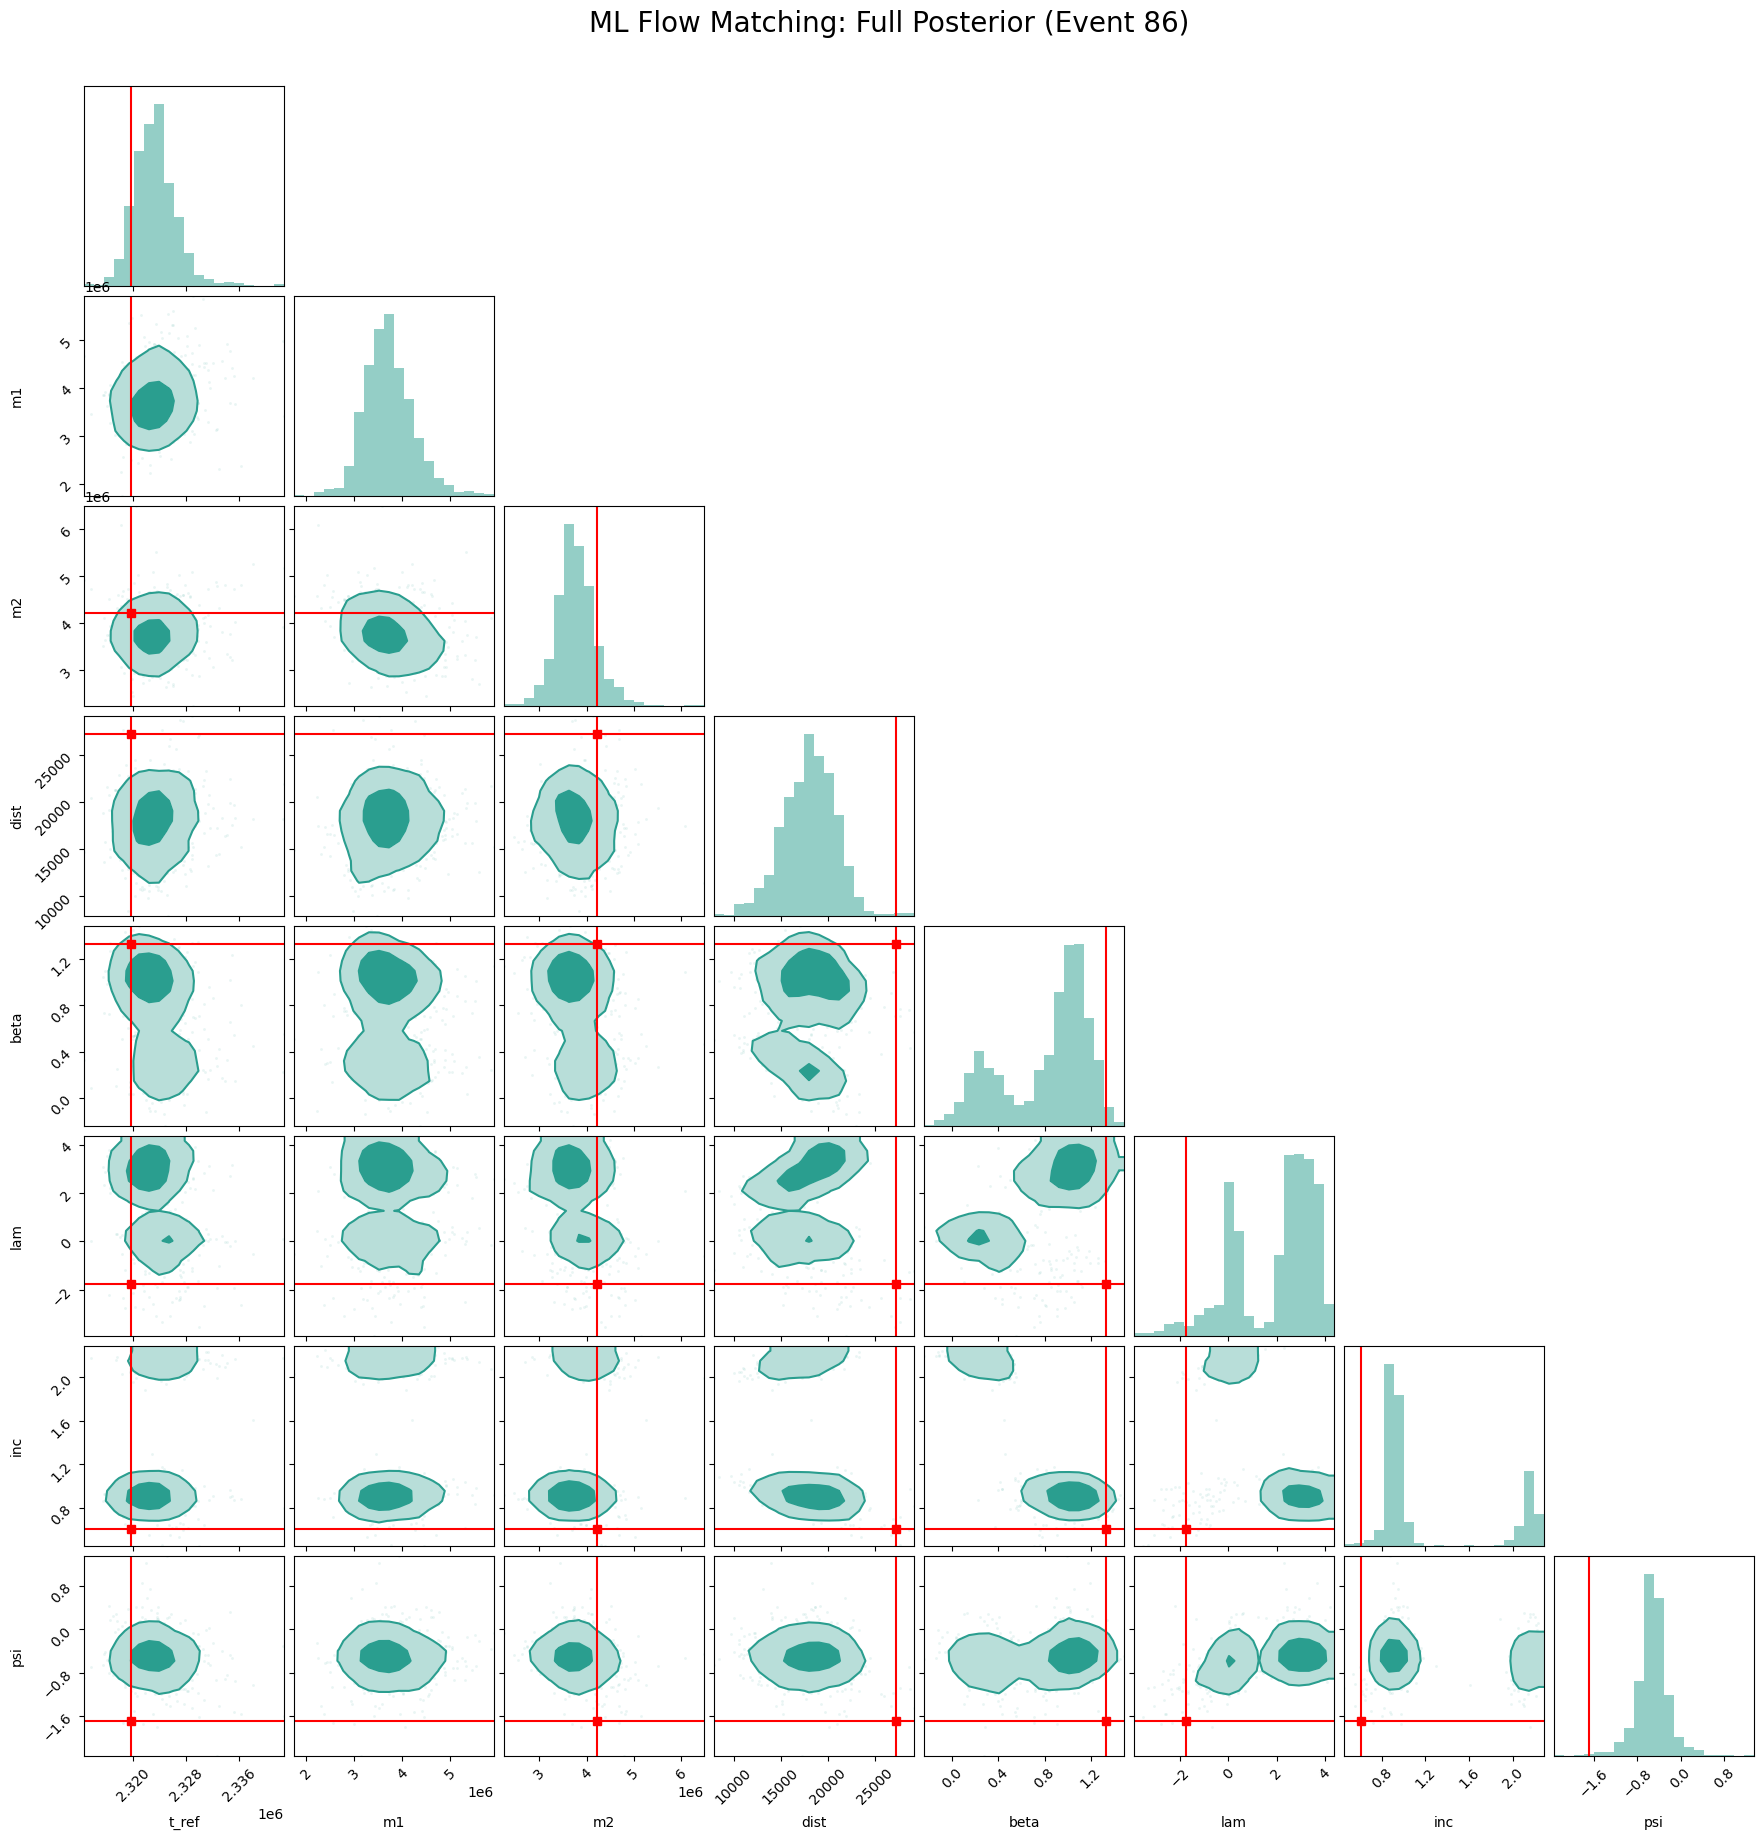

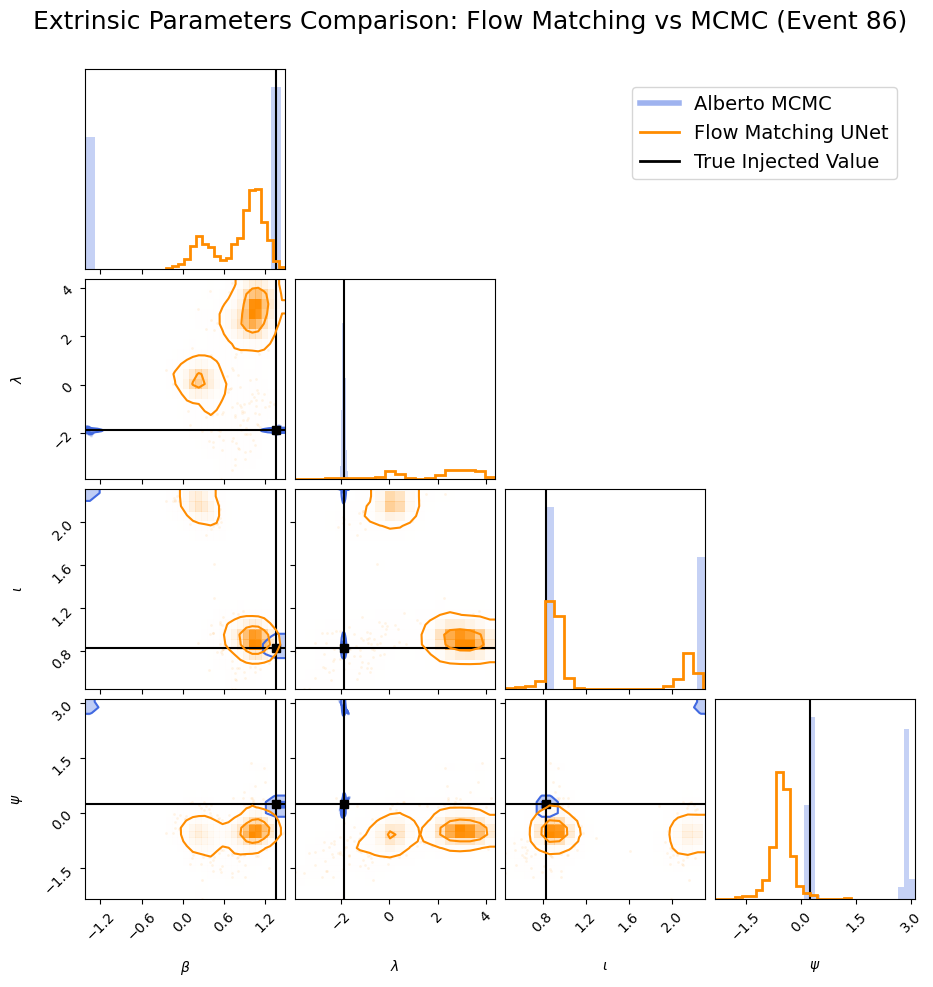

Done! Both plots saved.


In [3]:
import os
import sys
import h5py
import glob
import yaml
import torch
import numpy as np
import corner
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torchdiffeq
from bbhx.utils.constants import PC_SI

# Add your repository to the path so we can import the UNet!
sys.path.append("/sps/lisaf/mbellotti/github/lisaflow_cfm")
from torchcfm.models.unet import UNetModel
from examples.gw_mbhb.train_mbhb_malvi import LISAFlowDataset

# ==============================================================================
# 1. SETUP PATHS & LOAD ML DATASET
# ==============================================================================
JOB_ID = "42827953"  # Your full parameter space run
DATASET_NAME = "dataset_ae_stft_phase_100k.h5" 

TRAIN_DIR = "/sps/lisaf/mbellotti/github/lisaflow_cfm/examples/gw_mbhb"
checkpoint_path = os.path.join(TRAIN_DIR, f"malvis_tests/outputs/job_{JOB_ID}", "checkpoint_latest.pt")
dataset_path = os.path.join("/sps/lisaf/mbellotti/github/phd_disentangling/scripts/data", DATASET_NAME)
alberto_repo = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs"
pop_name = "Q3d"
event_id = 86  # Choose the event you want to compare

device = "cuda" if torch.cuda.is_available() else "cpu"

# Get the exact parameter order from the YAML file used in training
yaml_path = os.path.join(TRAIN_DIR, '../configs/mbhb/mbhb_params_mbhb4.yaml')
with open(yaml_path, 'r') as f:
    config_params = yaml.safe_load(f)

param_names = [key for key, val in config_params['estimate'].items() if val == 1]
print(f"Network was trained on these EXACT parameters: {param_names}")

dataset = LISAFlowDataset(dataset_path, param_names)

# ==============================================================================
# 2. LOAD ALBERTO'S 4D MCMC POSTERIORS
# ==============================================================================
print(f"\n--- Loading Extrinsic MCMC Posteriors for Event {event_id} ---")
h5_matches = glob.glob(os.path.join(alberto_repo, pop_name, "*inference*", f"*{event_id}*.h5"))
if not h5_matches: raise FileNotFoundError(f"Could not find MCMC file for event {event_id}!")

mcmc_dict = {}
true_dict = {}

with h5py.File(h5_matches[0], 'r') as f:
    if 'source_params_Lframe' in f:
        sp = f['source_params_Lframe']
        for name in sp.keys():
            val = sp[name][()]
            true_dict[name] = val[0] if isinstance(val, np.ndarray) else val

    for param in ['beta', 'lambda', 'inc', 'psi']:
        chain = f['Lframe'][param][:] if ('Lframe' in f and param in f['Lframe']) else f.get(param, None)
        if chain is not None:
            if len(chain.shape) == 3: chain = chain[0, :, chain.shape[2]//2:]
            elif len(chain.shape) == 2: chain = chain[:, chain.shape[1]//2:]
            else: chain = chain[chain.shape[0]//2:]
            mcmc_dict[param] = chain.flatten()
            
    if 'lnlike' in f:
        lnL = f['lnlike'][:]
        if len(lnL.shape) == 3: lnL = lnL[0, :, lnL.shape[2]//2:].flatten()
        elif len(lnL.shape) == 2: lnL = lnL[:, lnL.shape[1]//2:].flatten()
        else: lnL = lnL[lnL.shape[0]//2:].flatten()
        mask = lnL > -40.0
        for k in mcmc_dict:
            if len(mcmc_dict[k]) == len(mask):
                mcmc_dict[k] = mcmc_dict[k][mask]

# Stack MCMC into a 4D array: [beta, lam, inc, psi]
mcmc_extrinsic_samples = np.column_stack([
    mcmc_dict['beta'], mcmc_dict['lambda'], mcmc_dict['inc'], mcmc_dict['psi']
])

true_extrinsic = [
    true_dict.get('beta', np.median(mcmc_dict['beta'])),
    true_dict.get('lambda', np.median(mcmc_dict['lambda'])),
    true_dict.get('inc', np.median(mcmc_dict['inc'])),
    true_dict.get('psi', np.median(mcmc_dict['psi']))
]

# ==============================================================================
# 3. FIND EVENT IN ML DATASET & GENERATE FULL 7D POSTERIORS
# ==============================================================================
print(f"\n--- Loading ML Dataset & Finding Event ---")
# Match the event using sky coordinates
diff = (dataset.raw_param_dict['lam'] - true_extrinsic[1])**2 + (dataset.raw_param_dict['beta'] - true_extrinsic[0])**2
best_idx = np.argmin(diff)

print(f"Matched ML Dataset Index: {best_idx}")
print(f"Distance to Alberto's Sky Location: {diff[best_idx]:.2e} (Should be ~0 if it's the exact appended event!)")

target_params_norm, target_img_norm = dataset[best_idx]
target_img_norm = target_img_norm.unsqueeze(0).to(device)

H, W = target_img_norm.shape[-2], target_img_norm.shape[-1]
H_new, W_new = H - (H % 16), W - (W % 16)
target_img_norm = target_img_norm[:, :, :H_new, :W_new]
img_shape = (target_img_norm.shape[1], H_new, W_new)

print("\nLoading U-Net Checkpoint...")
model = UNetModel(
    dimx=(len(param_names), 1, 1), dimy=img_shape, 
    num_channels=32, num_res_blocks=1, channel_mult=(1, 2, 2), 
    class_cond=False, use_checkpoint=True, attention_resolutions="16"
).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=False)['model_state_dict'])
model.eval()

print("Generating 1000 Network Posteriors (Using High-Precision dopri5 in batches)...")
num_samples = 1000
batch_size_gen = 50  # Process in batches to prevent GPU memory spikes
samples_end_list = []

with torch.no_grad():
    for i in range(0, num_samples, batch_size_gen):
        n_samp = min(batch_size_gen, num_samples - i)
        img_batch = target_img_norm.expand(n_samp, -1, -1, -1)
        z0 = torch.randn((n_samp, len(param_names))).to(device).unsqueeze(1)
        
        # ---> THE CRITICAL FIX: EXPAND SCALAR TIME TO A 1D BATCH TENSOR <---
        def ode_wrapper(t, x):
            t_batched = t.expand(x.shape[0]).to(device)
            return model.forward(t_batched, x, img_batch, timefrequency=True)

        # Upgrade to dopri5 for perfectly accurate integration
        traj = torchdiffeq.odeint(
            ode_wrapper, 
            z0, 
            torch.linspace(0, 1, 50, device=device), 
            method="dopri5", atol=1e-4, rtol=1e-4
        )
        samples_end_list.append(traj[-1].view(n_samp, len(param_names)).cpu().numpy())

samples_norm = np.concatenate(samples_end_list, axis=0)

# Un-normalize back to physical parameters
ml_samples_full = samples_norm * dataset.param_std + dataset.param_mean

# Convert ML Distance from meters to Mpc for plotting
dist_idx = param_names.index('dist')
ml_samples_full[:, dist_idx] = ml_samples_full[:, dist_idx] / (1e6 * PC_SI)

# Get the True values from the dataset for Plot 1
true_full_values = dataset.params[best_idx].copy()
true_full_values[dist_idx] /= (1e6 * PC_SI)  # Also convert the true distance to Mpc

# ==============================================================================
# 4. PLOT 1: ML FULL POSTERIOR (ALL PARAMETERS)
# ==============================================================================
print("\nGenerating Plot 1: Full ML Posterior...")
fig1 = corner.corner(
    ml_samples_full,
    labels=param_names,
    truths=true_full_values, truth_color='red',
    color='#2A9E8F',
    hist_kwargs={'density': True, 'histtype': 'stepfilled', 'alpha': 0.5},
    smooth=0.8, fill_contours=True, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)
fig1.suptitle(f"ML Flow Matching: Full Posterior (Event {event_id})", fontsize=20, y=1.02)
plt.savefig(f"ML_Full_Event_{event_id}.png", dpi=150, bbox_inches='tight')

# ==============================================================================
# 5. PLOT 2: COMPARISON OF THE 4 EXTRINSIC PARAMETERS (ML vs MCMC)
# ==============================================================================
print("Generating Plot 2: 4D Extrinsic Comparison...")

# Dynamically find the indices of the 4 angles so the code never breaks!
idx_beta = param_names.index('beta')
idx_lam = param_names.index('lam')
idx_inc = param_names.index('inc')
idx_psi = param_names.index('psi')

# Slice the ML samples to only get [beta, lam, inc, psi]
ml_samples_extrinsic = ml_samples_full[:, [idx_beta, idx_lam, idx_inc, idx_psi]]
plot_labels_extrinsic = [r"$\beta$", r"$\lambda$", r"$\iota$", r"$\psi$"]

fig2 = corner.corner(
    mcmc_extrinsic_samples,
    labels=plot_labels_extrinsic, 
    truths=true_extrinsic, truth_color='black',
    color='royalblue',
    hist_kwargs={'density': True, 'histtype': 'stepfilled', 'alpha': 0.3},
    smooth=0.8, fill_contours=True, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)

corner.corner(
    ml_samples_extrinsic,
    fig=fig2, 
    color='darkorange',
    hist_kwargs={'density': True, 'histtype': 'step', 'linewidth': 2},
    smooth=0.8, fill_contours=False, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)

custom_lines = [
    Line2D([0], [0], color='royalblue', lw=4, alpha=0.5, label='Alberto MCMC'),
    Line2D([0], [0], color='darkorange', lw=2, label='Flow Matching UNet'),
    Line2D([0], [0], color='black', lw=2, label='True Injected Value')
]
fig2.legend(handles=custom_lines, loc='upper right', fontsize=14, bbox_to_anchor=(0.95, 0.95))
fig2.suptitle(f"Extrinsic Parameters Comparison: Flow Matching vs MCMC (Event {event_id})", fontsize=18, y=1.02)

plt.savefig(f"Extrinsic_Comparison_Event_{event_id}.png", dpi=150, bbox_inches='tight')

plt.show()
print("Done! Both plots saved.")

Network was trained on these EXACT parameters: ['t_ref', 'm1', 'm2', 'dist', 'beta', 'lam', 'inc', 'psi']

--- Finding the optimal ML Validation Event ---
Evaluating ML Event Index: 56410
Loading U-Net Checkpoint...
Generating 1000 Network Posteriors (In batches of 50 to prevent memory issues)...
Generating Plot 1: Full ML Posterior...


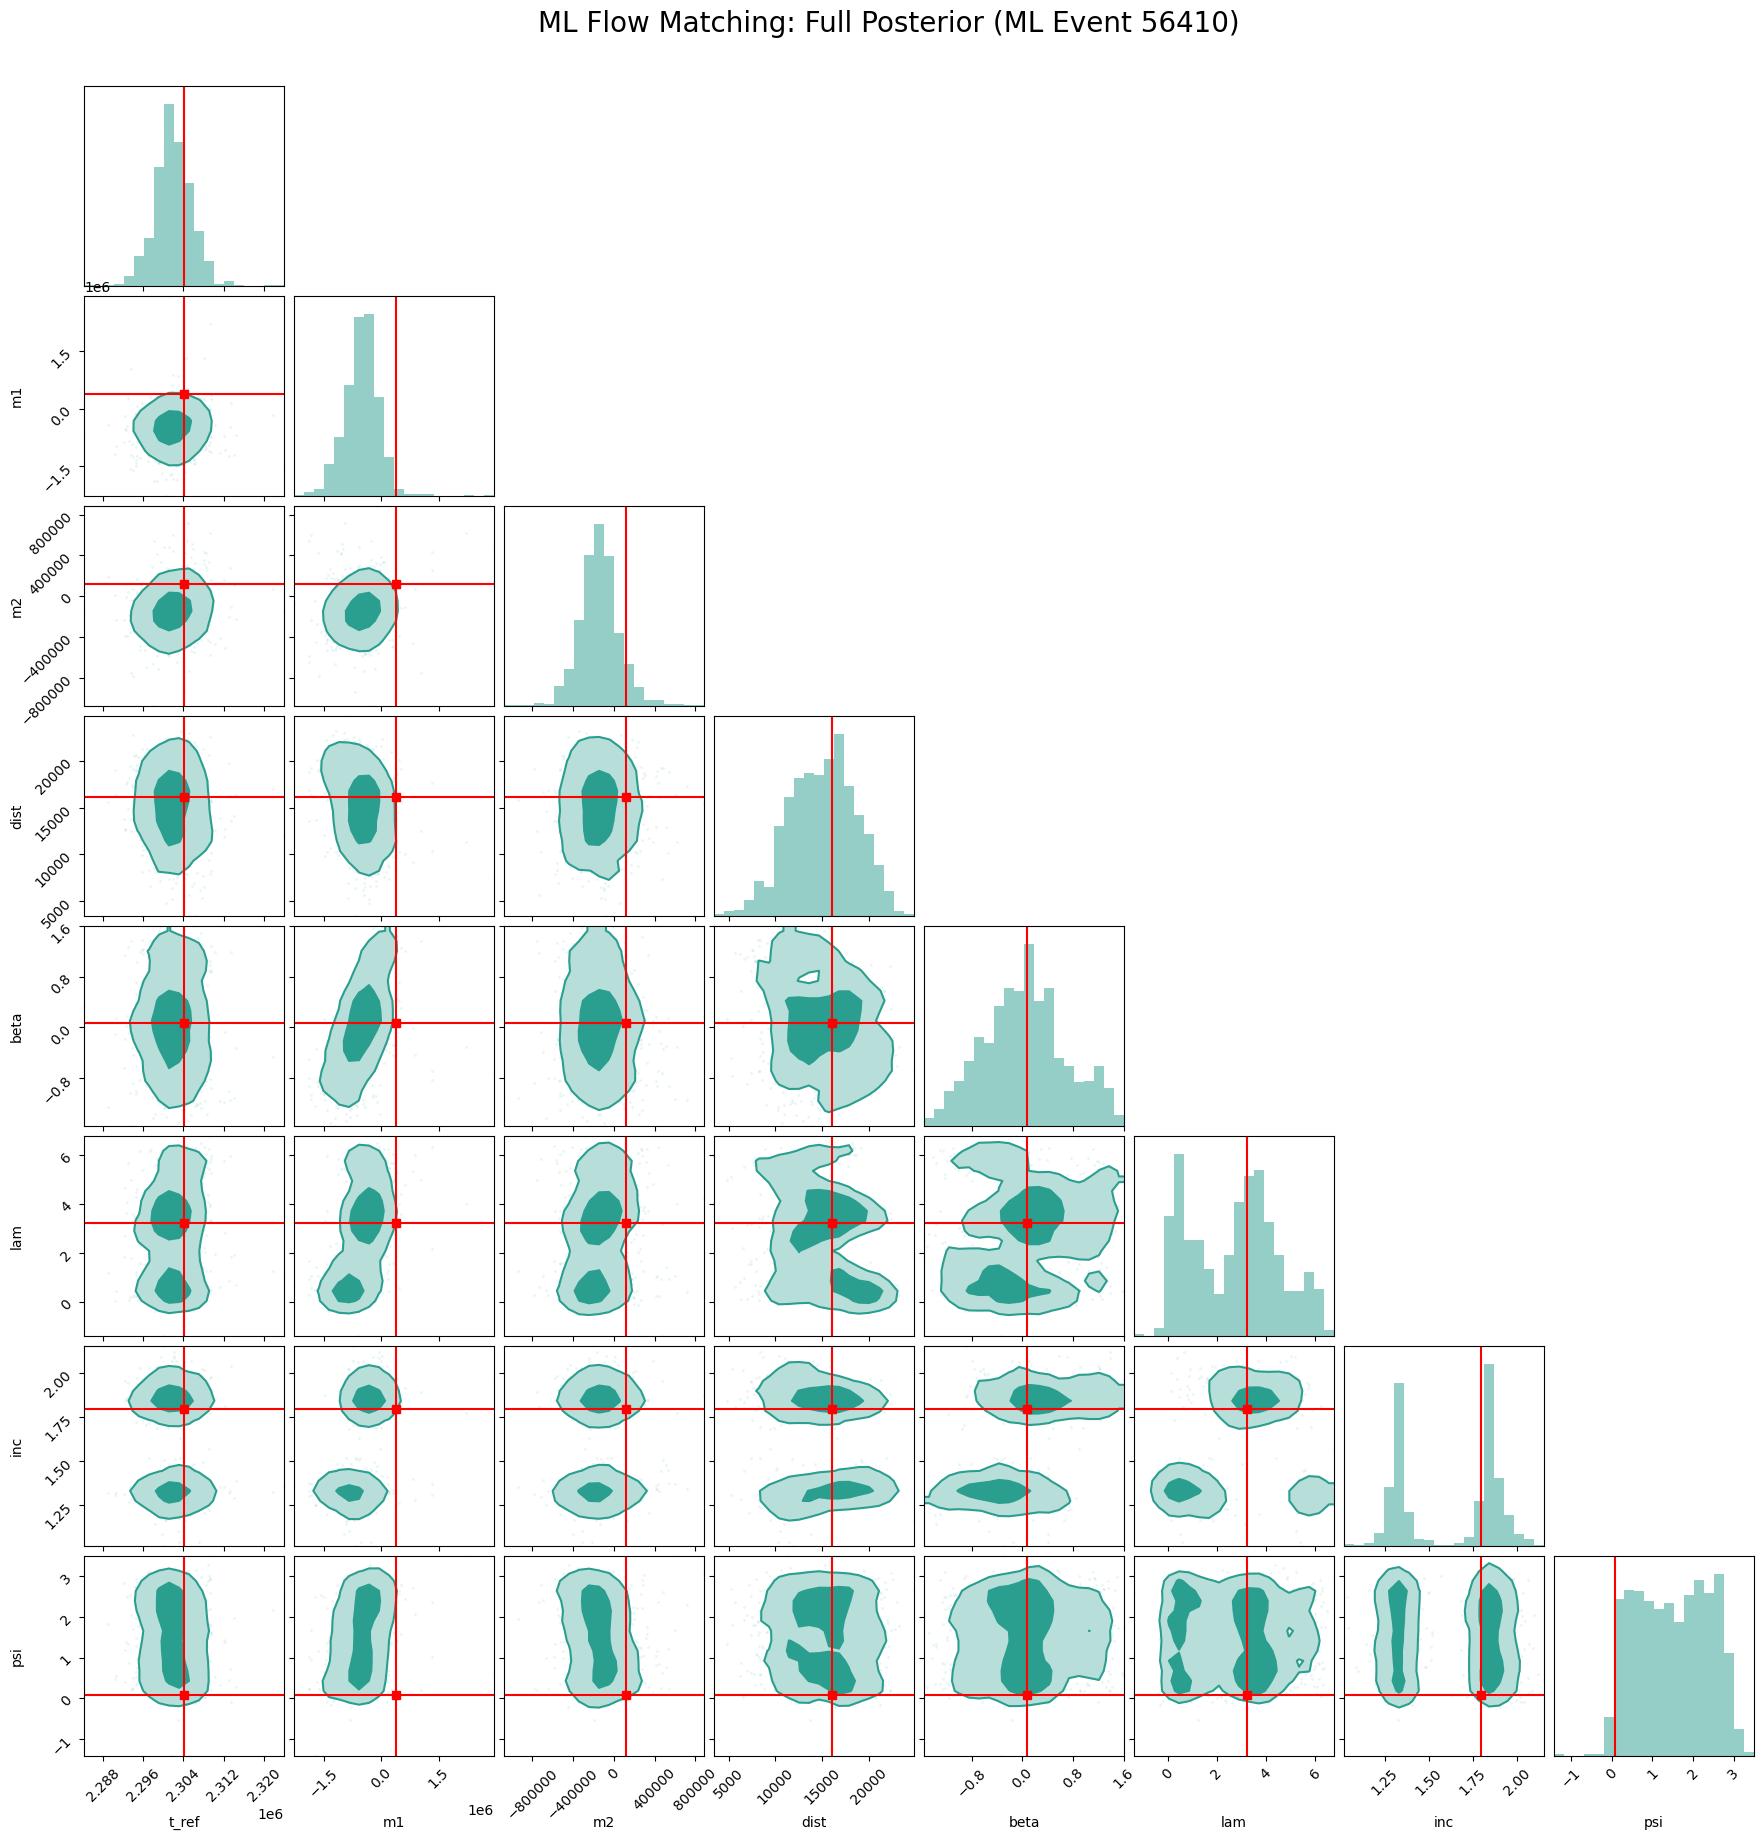

Done!


In [15]:
import os
import sys
import h5py
import glob
import yaml  # <--- WE NEED THIS TO GET THE CORRECT PARAMETER ORDER!
import torch
import numpy as np
import corner
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import torchdiffeq
from bbhx.utils.constants import PC_SI

# Add your repository to the path so we can import the UNet!
sys.path.append("/sps/lisaf/mbellotti/github/lisaflow_cfm")
from torchcfm.models.unet import UNetModel
from examples.gw_mbhb.train_mbhb_malvi import LISAFlowDataset

# ==============================================================================
# 1. SETUP PATHS
# ==============================================================================
JOB_ID = "42827953"  
DATASET_NAME = "dataset_ae_stft_phase_100k.h5" 

TRAIN_DIR = "/sps/lisaf/mbellotti/github/lisaflow_cfm/examples/gw_mbhb"
checkpoint_path = os.path.join(TRAIN_DIR, f"malvis_tests/outputs/job_{JOB_ID}", "checkpoint_latest.pt")
dataset_path = os.path.join("/sps/lisaf/mbellotti/github/phd_disentangling/scripts/data", DATASET_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"

# ==============================================================================
# 2. GET THE EXACT PARAMETER ORDER FROM YAML
# ==============================================================================
yaml_path = os.path.join(TRAIN_DIR, '../configs/mbhb/mbhb_params_mbhb4.yaml')
with open(yaml_path, 'r') as f:
    config_params = yaml.safe_load(f)

param_names = [key for key, val in config_params['estimate'].items() if val == 1]
print(f"Network was trained on these EXACT parameters: {param_names}")

dataset = LISAFlowDataset(dataset_path, param_names)

# ==============================================================================
# 3. FIND THE EXACT EVENT FROM YOUR VALIDATION LOOP
# ==============================================================================
print(f"\n--- Finding the optimal ML Validation Event ---")
# Let's find the exact event your validation script plotted to prove it works!
from astropy.cosmology import Planck18

m1_raw = dataset.raw_param_dict['m1']
q_raw  = dataset.raw_param_dict['q']
dist_raw = dataset.raw_param_dict['dist']
lam_raw = dataset.raw_param_dict['lam']
beta_raw = dataset.raw_param_dict['beta']

mtot_raw = m1_raw * (1 + q_raw)

target_z = 2.0
target_mtot = 5e5 
dl_mpc = Planck18.luminosity_distance(target_z).value
target_dist = dl_mpc * 1e6 * PC_SI 

score = (
    ((np.log10(mtot_raw) - np.log10(target_mtot)) / 1.0)**2 + 
    ((np.log10(dist_raw) - np.log10(target_dist)) / 0.5)**2 + 
    ((lam_raw - np.pi) / np.pi)**2 + 
    ((beta_raw - 0.0) / (np.pi/2))**2
)

best_idx = np.argmin(score)
print(f"Evaluating ML Event Index: {best_idx}")

# ==============================================================================
# 4. GENERATE POSTERIORS
# ==============================================================================
target_params_norm, target_img_norm = dataset[best_idx]
target_img_norm = target_img_norm.unsqueeze(0).to(device)

H, W = target_img_norm.shape[-2], target_img_norm.shape[-1]
H_new, W_new = H - (H % 16), W - (W % 16)
target_img_norm = target_img_norm[:, :, :H_new, :W_new]
img_shape = (target_img_norm.shape[1], H_new, W_new)

print("Loading U-Net Checkpoint...")
model = UNetModel(
    dimx=(len(param_names), 1, 1), dimy=img_shape, 
    num_channels=32, num_res_blocks=1, channel_mult=(1, 2, 2), 
    class_cond=False, use_checkpoint=True, attention_resolutions="16"
).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=False)['model_state_dict'])
model.eval()

print("Generating 1000 Network Posteriors (In batches of 50 to prevent memory issues)...")
num_samples = 1000
batch_size_gen = 50
samples_end_list = []

with torch.no_grad():
    for i in range(0, num_samples, batch_size_gen):
        n_samp = min(batch_size_gen, num_samples - i)
        img_batch = target_img_norm.expand(n_samp, -1, -1, -1)
        z0 = torch.randn((n_samp, len(param_names))).to(device).unsqueeze(1)
        
        traj = torchdiffeq.odeint(
            lambda t, x: model.forward(t, x, img_batch, timefrequency=True), 
            z0, torch.linspace(0, 1, 50, device=device), method="euler"
        )
        samples_end_list.append(traj[-1].view(n_samp, len(param_names)).cpu().numpy())

samples_norm = np.concatenate(samples_end_list, axis=0)

# Un-normalize back to physical parameters
ml_samples_full = samples_norm * dataset.param_std + dataset.param_mean

# Get true values
true_7d_values = dataset.params[best_idx].copy()

# Fix Distance Scaling for both prediction and truth if 'dist' is in the list
if 'dist' in param_names:
    dist_idx = param_names.index('dist')
    ml_samples_full[:, dist_idx] /= (1e6 * PC_SI)
    true_7d_values[dist_idx] /= (1e6 * PC_SI)

# ==============================================================================
# 5. PLOT ML ONLY (NO ALBERTO COMPARISON YET)
# ==============================================================================
print("Generating Plot 1: Full ML Posterior...")
fig1 = corner.corner(
    ml_samples_full,
    labels=param_names, # Use the exact names loaded from YAML
    truths=true_7d_values, truth_color='red',
    color='#2A9E8F',
    hist_kwargs={'density': True, 'histtype': 'stepfilled', 'alpha': 0.5},
    smooth=0.8, fill_contours=True, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
)
fig1.suptitle(f"ML Flow Matching: Full Posterior (ML Event {best_idx})", fontsize=20, y=1.02)
plt.savefig(f"ML_Only_Event_{best_idx}.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

In [17]:
# ==============================================================================
# 3. GRAB AN ALBERTO BENCHMARK EVENT
# ==============================================================================
print(f"\n--- Finding Alberto's Benchmark Event ---")

# Alberto's events were appended to the very end of the dataset!
# Let's just grab the last event in the file.
best_idx = len(dataset) - 1 

print(f"Evaluating Alberto Benchmark Event (Dataset Index: {best_idx})")

target_params_norm, target_img_norm = dataset[best_idx]
target_img_norm = target_img_norm.unsqueeze(0).to(device)

H, W = target_img_norm.shape[-2], target_img_norm.shape[-1]
H_new, W_new = H - (H % 16), W - (W % 16)
target_img_norm = target_img_norm[:, :, :H_new, :W_new]
img_shape = (target_img_norm.shape[1], H_new, W_new)

# ==============================================================================
# 4. GENERATE HIGH-QUALITY POSTERIORS
# ==============================================================================
print("Loading U-Net Checkpoint...")
model = UNetModel(
    dimx=(len(param_names), 1, 1), dimy=img_shape, 
    num_channels=32, num_res_blocks=1, channel_mult=(1, 2, 2), 
    class_cond=False, use_checkpoint=True, attention_resolutions="16"
).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=False)['model_state_dict'])
model.eval()

print("Generating 1000 Network Posteriors (Using High-Precision dopri5)...")
num_samples = 1000
batch_size_gen = 50
samples_end_list = []

with torch.no_grad():
    for i in range(0, num_samples, batch_size_gen):
        n_samp = min(batch_size_gen, num_samples - i)
        img_batch = target_img_norm.expand(n_samp, -1, -1, -1)
        z0 = torch.randn((n_samp, len(param_names))).to(device).unsqueeze(1)
        
        # ---> UPGRADED TO DOPRI5 FOR MAXIMUM QUALITY <---
        traj = torchdiffeq.odeint(
            lambda t, x: model.forward(t, x, img_batch, timefrequency=True), 
            z0, torch.linspace(0, 1, 100, device=device),  # 100 steps
            method="dopri5", atol=1e-4, rtol=1e-4
        )
        samples_end_list.append(traj[-1].view(n_samp, len(param_names)).cpu().numpy())

samples_norm = np.concatenate(samples_end_list, axis=0)

# Un-normalize back to physical parameters
ml_samples_full = samples_norm * dataset.param_std + dataset.param_mean

# Get true values
true_7d_values = dataset.params[best_idx].copy()

if 'dist' in param_names:
    dist_idx = param_names.index('dist')
    ml_samples_full[:, dist_idx] /= (1e6 * PC_SI)
    true_7d_values[dist_idx] /= (1e6 * PC_SI)


--- Finding Alberto's Benchmark Event ---
Evaluating Alberto Benchmark Event (Dataset Index: 100332)
Loading U-Net Checkpoint...
Generating 1000 Network Posteriors (Using High-Precision dopri5)...


In [16]:
# ==============================================================================
# 3. EVALUATE ON 3 RANDOM EVENTS TO CHECK NETWORK HEALTH
# ==============================================================================
print("Loading U-Net Checkpoint...")
model = UNetModel(
    dimx=(len(param_names), 1, 1), dimy=(dataset[0][1].shape[1], dataset[0][1].shape[2] - (dataset[0][1].shape[2] % 16)), 
    num_channels=32, num_res_blocks=1, channel_mult=(1, 2, 2), 
    class_cond=False, use_checkpoint=True, attention_resolutions="16"
).to(device)

# TRY CHANGING THIS TO AN EARLIER EPOCH (e.g. checkpoint_epoch_50.pt)
model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=False)['model_state_dict'])
model.eval()

# Pick 3 random events from the dataset
np.random.seed(42)
test_indices = np.random.choice(len(dataset), 3, replace=False)

for i, test_idx in enumerate(test_indices):
    print(f"\nEvaluating Random Event {test_idx} ({i+1}/3)...")
    
    # 1. Get Image and True Params
    target_params_norm, target_img_norm = dataset[test_idx]
    
    H, W = target_img_norm.shape[-2], target_img_norm.shape[-1]
    H_new, W_new = H - (H % 16), W - (W % 16)
    target_img_norm = target_img_norm[:, :H_new, :W_new].unsqueeze(0).to(device)
    
    # 2. Generate Posteriors
    num_samples = 1000
    with torch.no_grad():
        img_batch = target_img_norm.expand(num_samples, -1, -1, -1)
        z0 = torch.randn((num_samples, len(param_names))).to(device).unsqueeze(1)
        
        traj = torchdiffeq.odeint(
            lambda t, x: model.forward(t, x, img_batch, timefrequency=True), 
            z0, torch.linspace(0, 1, 50, device=device), method="euler"
        )
        samples_norm = traj[-1].view(num_samples, len(param_names)).cpu().numpy()

    # 3. Un-normalize
    ml_samples_full = samples_norm * dataset.param_std + dataset.param_mean
    true_7d_values = dataset.params[test_idx].copy()

    if 'dist' in param_names:
        dist_idx = param_names.index('dist')
        ml_samples_full[:, dist_idx] /= (1e6 * PC_SI)
        true_7d_values[dist_idx] /= (1e6 * PC_SI)

    # 4. Plot
    plot_labels_full = [r"$t_{ref}$", r"$m_1\ [M_\odot]$", r"$m_2\ [M_\odot]$", r"$D_L\ [\rm{Mpc}]$", r"$\beta$", r"$\lambda$", r"$\iota$", r"$\psi$"]
    
    fig1 = corner.corner(
        ml_samples_full, labels=plot_labels_full,
        truths=true_7d_values, truth_color='red', color='#2A9E8F',
        hist_kwargs={'density': True, 'histtype': 'stepfilled', 'alpha': 0.5},
        smooth=0.8, fill_contours=True, levels=(1 - np.exp(-0.5), 1 - np.exp(-2))
    )
    fig1.suptitle(f"ML Health Check: Event {test_idx}", fontsize=20, y=1.02)
    plt.savefig(f"Health_Check_Event_{test_idx}.png", dpi=150, bbox_inches='tight')
    plt.close()
    
print("\nDone! Check the 3 Health_Check plots.")

Loading U-Net Checkpoint...


RuntimeError: Error(s) in loading state_dict for UNetModelWrapper:
	size mismatch for init_conv.weight: copying a param with shape torch.Size([32, 12, 3, 3]) from checkpoint, the shape in current model is torch.Size([32, 110, 3, 3]).

In [1]:
import os
import glob
import re

repo_path = "/sps/lisaf/mbellotti/github/standard-sirens-MBHBs"
populations = ["Pop3", "Q3d", "Q3nd"]

print(f"--- Exploring Repository: {repo_path} ---\n")

for pop in populations:
    print(f"========== Population: {pop} ==========")
    
    # 1. Check for inference directories (could be 'inference_data' or 'data_inference')
    inf_dirs = glob.glob(os.path.join(repo_path, pop, "*infer*"))
    
    if not inf_dirs:
        print("  -> No inference directories found!")
        continue
        
    for d in inf_dirs:
        dir_name = os.path.basename(d)
        h5_files = glob.glob(os.path.join(d, "*.h5"))
        print(f"Found folder: '{dir_name}' containing {len(h5_files)} .h5 files.")
        
        if len(h5_files) > 0:
            print("  -> Example filenames:")
            for f in h5_files[:5]:
                print(f"       {os.path.basename(f)}")
            
            # Extract the IDs from the filenames
            valid_ids = []
            for f in h5_files:
                filename = os.path.basename(f)
                # Find all numbers in the filename
                numbers = re.findall(r'\d+', filename)
                if numbers:
                    # Usually, the very last number in the filename is the Event ID
                    valid_ids.append(int(numbers[-1]))
            
            valid_ids.sort()
            print(f"  -> Valid Event IDs you can use (first 30):")
            print(f"       {valid_ids[:30]}\n")

--- Exploring Repository: /sps/lisaf/mbellotti/github/standard-sirens-MBHBs ---

========== Population: Pop3 ==========
Found folder: 'inference_data' containing 1272 .h5 files.
  -> Example filenames:
       smbh_pt_8modes_Pop3_295.h5
       smbh_pt_8modes_Pop3_645.h5
       smbh_pt_8modes_Pop3_669.h5
       smbh_pt_8modes_Pop3_500.h5
       smbh_pt_8modes_Pop3_137.h5
  -> Valid Event IDs you can use (first 30):
       [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

========== Population: Q3d ==========
Found folder: 'inference_data' containing 584 .h5 files.
  -> Example filenames:
       smbh_pt_8modes_Q3d_225.h5
       smbh_pt_8modes_Q3d_102.h5
       smbh_pt_8modes_Q3d_8.h5
       smbh_pt_8modes_Q3d_124.h5
       smbh_pt_8modes_Q3d_262.h5
  -> Valid Event IDs you can use (first 30):
       [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

========== Population: Q3nd ==========
Found folder: 'infe

In [ ]:
import fix_cupy
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft, windows
import scipy.signal as signal

from bbhx.waveformbuild import BBHWaveformFD
from bbhx.utils.constants import YRSID_SI, PC_SI 
from gbgpu.gbgpu import GBGPU
from gwpy.timeseries import TimeSeries

from kymatio.numpy import Scattering1D

dt = 10.0                       
fs = 1.0 / dt                   
Tobs = 2 * 24 * 3600            

N = 2**int(np.floor(np.log2(Tobs / dt)))
Tobs = N * dt                   
df = 1.0 / Tobs
t = np.arange(N) * dt
freqs_fft = np.fft.rfftfreq(N, dt)

print(f"Observation: {Tobs/3600:.1f} hours")
print(f"Points (N): {N}")
print(f"Nyquist Freq: {fs/2:.2f} Hz")
orbits = EqualArmlengthOrbits(use_gpu=True, force_backend="cuda")
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False), response_kwargs=dict(orbits=orbits), force_backend="cuda")

m1, m2 = 5e5, 4e5
t_ref = Tobs * 0.8  
dist = 20 * PC_SI * 1e6
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave_mbhb = wave_gen(
    m1, m2, 0.2, 0.4, dist,
    0.0, 0.0, np.pi/3, np.pi/5, np.pi/4, np.pi/6, t_ref,
    t_obs_start=0.0, t_obs_end=Tobs, 
    freqs=freqs_fft, modes=modes, direct=False, fill=True, length=N
)[0]

h_mbhb_td = np.fft.irfft(wave_mbhb[0], n=N)

gb = GBGPU(force_backend="gpu")

amp = np.array([3e-22, 2e-22, 8e-22])
f0 = np.array([2.0e-3, 5.5e-3, 3.0e-3])
fdot = np.array([1e-17, 1e-17, 1e-17])
zeros = np.zeros(3)
params = np.array([amp, f0, fdot, zeros, zeros, zeros+0.5, zeros, zeros, zeros])

gb.run_wave(*params, N=N, dt=dt, T=Tobs, oversample=2)
A_gb_fd = gb.A 

h_gb_fd = np.zeros_like(freqs_fft, dtype=complex)
for i in range(3):
    h_gb_fd += np.interp(freqs_fft, gb.freqs[i], A_gb_fd[i].real) + \
               1j * np.interp(freqs_fft, gb.freqs[i], A_gb_fd[i].imag)

h_gb_td = np.fft.irfft(h_gb_fd, n=N)

np.random.seed(42)
noise_amp = 1e-21 
noise = np.random.normal(0, noise_amp, N)

h_mix = h_mbhb_td + h_gb_td + noise

print("Data Generation Complete.")




nperseg_short = 1024
noverlap = int(nperseg_short * 4 / 5)
hop_length = nperseg_short - noverlap

window = torch.hann_window(nperseg_short)

Z_s = torch.stft(
    h_torch,
    n_fft=nperseg_short,
    hop_length=hop_length,
    window=window,
    return_complex=True
)

Z_s_mag = torch.abs(Z_s).numpy()

f_s = torch.fft.rfftfreq(nperseg_short, d=1/fs).numpy()

t_s = np.arange(Z_s.shape[1]) * hop_length / fs
plt.title("STFT: short window (torch)")
plt.ylim(1e-4, 1e-2)
plt.yscale('log')
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [hours]")

plt.pcolormesh(
    t_s/3600,
    f_s,
    np.log10(Z_s_mag),
    shading='gouraud',
    cmap='viridis'
)


